Nombre: Emilio Rico Hernández
Clase: 2
Challenge: Data Detective
Fecha: 2026-09-25

# Challenge 2 — Data Detective

Uso `clientes_app.csv`, la base de la práctica integradora (la renombré en mi carpeta): cada fila es un cliente de un servicio con app y planes de suscripción, con su plan, ciudad, uso de la app, gasto, satisfacción y si abandonó (`churn`). La elegí porque tiene variables numéricas y categóricas y problemas de calidad útiles para la auditoría.

El objetivo es encontrar al menos cinco hallazgos con evidencia.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# utf-8-sig porque el archivo trae BOM y sin eso la primera columna sale con un carácter raro
df = pd.read_csv("clientes_app.csv", encoding="utf-8-sig")
df.head()

,id_cliente,fecha,edad,ciudad,plan,canal_adquisicion,antiguedad_meses,sesiones_mes,minutos_app,tickets_soporte,satisfaccion,descuento_pct,ingreso_mensual,gasto_mensual,compras_mes,mora_dias,calificacion,review,sentimiento,churn,gasto_proximo_mes
0,C00630,2026-04-23,50,CDMX,Básico,Orgánico,6,10,322.6,1,7.3,15,42281.61,272.61,2,16,4,la aplicación falla mucho y estoy muy decepcio...,negativo,1,162.65
1,C01050,2025-01-26,54,Monterrey,Básico,Evento,21,14,290.8,0,8.9,10,31258.61,224.23,1,1,5,"me gustó mucho la atención, resolvieron rápido...",positivo,0,301.64
2,C01455,2025-01-19,49,Monterrey,Premium,Orgánico,9,15,279.3,0,10.0,0,NaN,894.71,3,3,5,la plataforma es muy útil y el precio me parec...,positivo,0,1041.04
3,C00754,2026-08-16,39,Querétaro,Básico,Referido,11,8,156.8,1,6.5,0,41377.66,291.07,2,3,4,todavía estoy evaluando si continuar con el se...,neutral,0,353.21
4,C00004,2025-11-12,22,Monterrey,Premium,Anuncio,5,18,510.3,0,9.0,15,29725.55,703.45,3,0,5,estoy muy satisfecho con el plan y lo recomiendo,positivo,0,867.76


## Fase 1 — Auditoría

In [2]:
print("Dimensiones:", df.shape)
df.info()

Dimensiones: (1840, 21)
<class 'pandas.DataFrame'>
RangeIndex: 1840 entries, 0 to 1839
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_cliente         1840 non-null   str    
 1   fecha              1840 non-null   str    
 2   edad               1840 non-null   int64  
 3   ciudad             1816 non-null   str    
 4   plan               1840 non-null   str    
 5   canal_adquisicion  1840 non-null   str    
 6   antiguedad_meses   1840 non-null   int64  
 7   sesiones_mes       1840 non-null   int64  
 8   minutos_app        1803 non-null   float64
 9   tickets_soporte    1840 non-null   int64  
 10  satisfaccion       1794 non-null   float64
 11  descuento_pct      1840 non-null   int64  
 12  ingreso_mensual    1777 non-null   float64
 13  gasto_mensual      1840 non-null   float64
 14  compras_mes        1840 non-null   int64  
 15  mora_dias          1840 non-null   int64  
 16  calificacio

In [3]:
print("Valores faltantes por columna:")
print(df.isna().sum())

Valores faltantes por columna:
id_cliente            0
fecha                 0
edad                  0
ciudad               24
plan                  0
canal_adquisicion     0
antiguedad_meses      0
sesiones_mes          0
minutos_app          37
tickets_soporte       0
satisfaccion         46
descuento_pct         0
ingreso_mensual      63
gasto_mensual         0
compras_mes           0
mora_dias             0
calificacion          0
review               27
sentimiento           0
churn                 0
gasto_proximo_mes     0
dtype: int64


In [4]:
print("Filas duplicadas:", df.duplicated().sum())
print("id_cliente repetidos:", df["id_cliente"].duplicated().sum())

Filas duplicadas: 40
id_cliente repetidos: 40


In [5]:
df.nunique()

id_cliente           1800
fecha                 580
edad                   53
ciudad                  5
plan                    3
canal_adquisicion       5
antiguedad_meses       72
sesiones_mes           37
minutos_app          1483
tickets_soporte         5
satisfaccion           54
descuento_pct           6
ingreso_mensual      1737
gasto_mensual        1767
compras_mes             8
mora_dias              22
calificacion            4
review                 17
sentimiento             3
churn                   2
gasto_proximo_mes    1771
dtype: int64

- **Dimensiones y tipos:** 1,840 filas y 21 columnas (9 enteras, 5 decimales y 7 de texto). `fecha` viene como texto, pero no la uso.
- **Faltantes:** nulos en cinco columnas: `ingreso_mensual` (63), `satisfaccion` (46), `minutos_app` (37), `review` (27) y `ciudad` (24). El mayor es 3.4%, no es grave.
- **Duplicados:** 40 filas duplicadas exactas (2.2%). Como también hay 40 `id_cliente` repetidos, cada id repetido es un cliente capturado dos veces. Quedan 1,800 clientes únicos.
- **Únicos:** `plan` tiene 3 valores, `ciudad` 5, `canal_adquisicion` 5 y `churn` 2. `review` tiene solo 17 textos distintos para 1,800 clientes, parecen reseñas de plantilla.

Sigo con una copia sin duplicados exactos y dejo los nulos, porque pandas los ignora en promedios.

In [6]:
# Trabajo sin los duplicados exactos; los nulos no los toco porque pandas los ignora en media, mediana, etc.
d = df.drop_duplicates()
print("Filas para el análisis:", len(d))

Filas para el análisis: 1800


## Fase 2 — Distribuciones

Elijo tres variables numéricas: `gasto_mensual`, `ingreso_mensual` y `minutos_app`.

In [7]:
vars_num = ["gasto_mensual", "ingreso_mensual", "minutos_app"]
d[vars_num].describe().round(2)

,gasto_mensual,ingreso_mensual,minutos_app
count,1800.00,1737.00,1764.00
mean,457.11,31260.71,342.96
std,423.02,18890.40,488.35
min,80.00,6839.87,0.00
25%,249.16,24372.99,189.08
50%,415.58,30175.90,303.35
75%,528.16,35956.75,425.18
max,7416.36,326069.06,8751.60


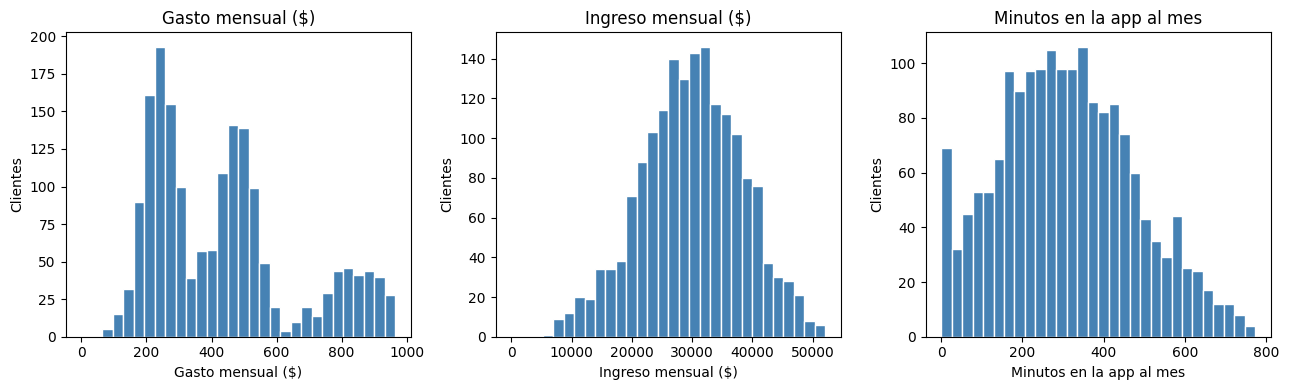

In [8]:
etiquetas = ["Gasto mensual ($)", "Ingreso mensual ($)", "Minutos en la app al mes"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, etiqueta in zip(axes, vars_num, etiquetas):
    # recorto en el percentil 99 para que se vea la forma; los valores extremos los comento en el texto
    ax.hist(d[col].dropna(), bins=30, range=(0, d[col].quantile(0.99)), color="steelblue", edgecolor="white")
    ax.set_title(etiqueta)
    ax.set_xlabel(etiqueta)
    ax.set_ylabel("Clientes")
plt.tight_layout()
plt.show()

- **`gasto_mensual`:** media $457 y mediana $416, con la mitad central entre $249 y $528. El máximo es $7,416, casi 18 veces la mediana. El histograma muestra tres montones (cerca de $250, $480 y $880) que parecen ser los tres planes.
- **`ingreso_mensual`:** media $31,261 y mediana $30,176, en forma de campana, pero con un máximo de $326,069 (unas 11 veces la mediana).
- **`minutos_app`:** media 343 y mediana 303, con un grupo pegado a cero y un máximo de 8,752 minutos (unas 146 horas al mes), poco realista.

En las tres la media es solo 1.04 a 1.13 veces la mediana: las colas las estiran pocos valores extremos. Recorté los histogramas en el percentil 99 para ver la forma.

## Fase 3 — Variables categóricas

In [9]:
for col in ["plan", "ciudad", "canal_adquisicion", "churn"]:
    print(d[col].value_counts(normalize=True).mul(100).round(1))
    print()

plan
Básico      42.7
Estándar    38.6
Premium     18.7
Name: proportion, dtype: float64

ciudad
CDMX           35.5
Guadalajara    20.9
Monterrey      17.8
Querétaro      13.3
Puebla         12.5
Name: proportion, dtype: float64

canal_adquisicion
Orgánico    28.6
Anuncio     23.9
Email       17.7
Referido    17.6
Evento      12.3
Name: proportion, dtype: float64

churn
0    91.9
1     8.1
Name: proportion, dtype: float64



- **`plan`:** el más frecuente es Básico (42.7%) y el menos frecuente Premium (18.7%).
- **`ciudad`:** CDMX es la más frecuente (35.5%) y Puebla la menos (12.5%).
- **`canal_adquisicion`:** Orgánico es el principal (28.6%) y Evento el menor (12.3%).
- **`churn`:** 91.9% se queda y 8.1% abandona, el desbalance más marcado. Un modelo que dijera siempre "no abandona" acertaría 92% sin aprender nada, así que habría que mirar recall o F1 y no solo accuracy.

En las otras tres la categoría más grande es entre 2 y 3 veces la más pequeña: desbalance moderado.

## Fase 4 — Relaciones

### Numérica vs numérica

descuento_pct       -0.09
churn               -0.08
tickets_soporte     -0.07
ingreso_mensual      0.00
edad                 0.01
antiguedad_meses     0.02
mora_dias            0.02
calificacion         0.06
satisfaccion         0.07
minutos_app          0.08
compras_mes          0.26
sesiones_mes         0.32
gasto_proximo_mes    0.47
Name: gasto_mensual, dtype: float64
Clientes con gasto mayor a $1,100: 6


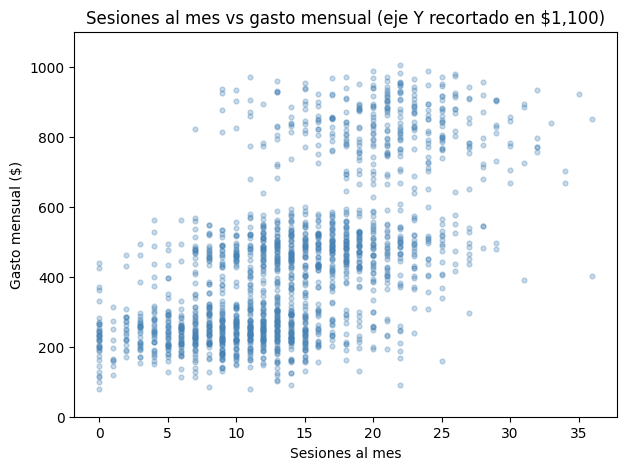

In [10]:
# Correlación del gasto mensual con las demás variables numéricas
print(d.corr(numeric_only=True)["gasto_mensual"].drop("gasto_mensual").round(2).sort_values())

print("Clientes con gasto mayor a $1,100:", (d["gasto_mensual"] > 1100).sum())

plt.figure(figsize=(7, 5))
plt.scatter(d["sesiones_mes"], d["gasto_mensual"], alpha=0.3, s=12, color="steelblue")
plt.ylim(0, 1100)   # recorto el eje Y para ver la nube; los pocos gastos extremos quedan fuera
plt.title("Sesiones al mes vs gasto mensual (eje Y recortado en $1,100)")
plt.xlabel("Sesiones al mes")
plt.ylabel("Gasto mensual ($)")
plt.show()

`gasto_proximo_mes` es la más correlacionada con `gasto_mensual` (0.47), lo cual es lógico porque es el gasto del mes siguiente. Después van `sesiones_mes` (0.32) y `compras_mes` (0.26), mientras que `ingreso_mensual` (0.00) y `edad` (0.01) no tienen relación.

En la gráfica hay una tendencia ascendente con dos bloques: uno abajo de $600 y otro de alrededor de $700 a $1,000 que aparece desde unas 7 sesiones (dejé fuera 6 clientes con gasto mayor a $1,100). La correlación es moderada porque el gasto salta por bloques, y que dos variables vayan juntas no significa que una cause la otra.

### Categórica vs numérica

          gasto_mensual  ingreso_mensual  satisfaccion  sesiones_mes
plan                                                                
Básico            270.2          31291.2           8.0           9.9
Estándar          484.6          31041.2           8.4          15.4
Premium           827.9          31653.0           8.4          21.1


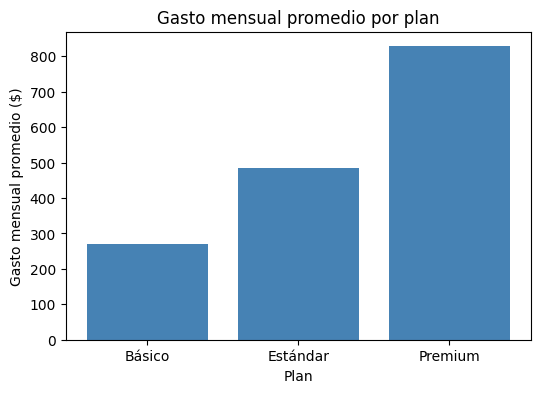

In [11]:
por_plan = d.groupby("plan")[["gasto_mensual", "ingreso_mensual", "satisfaccion", "sesiones_mes"]].mean().round(1)
print(por_plan)

plt.figure(figsize=(6, 4))
plt.bar(por_plan.index, por_plan["gasto_mensual"], color="steelblue")
plt.title("Gasto mensual promedio por plan")
plt.xlabel("Plan")
plt.ylabel("Gasto mensual promedio ($)")
plt.show()

El gasto sube mucho con el plan: $270 en Básico, $485 en Estándar y $828 en Premium, unas 3 veces más en Premium que en Básico. El ingreso es casi igual en los tres (alrededor de $31,000) y la satisfacción cambia poco (8.0 contra 8.4). Los planes más caros usan más la app: 9.9, 15.4 y 21.1 sesiones al mes.

Esto explica los bloques del scatter. Sospecho que `gasto_mensual` incluye el costo del plan, así que la diferencia sería en parte mecánica; habría que confirmarlo con el diccionario de datos.

### Categórica vs categórica

churn       0   1  tasa_churn_%
plan                           
Básico    674  95          12.4
Estándar  657  38           5.5
Premium   323  13           3.9


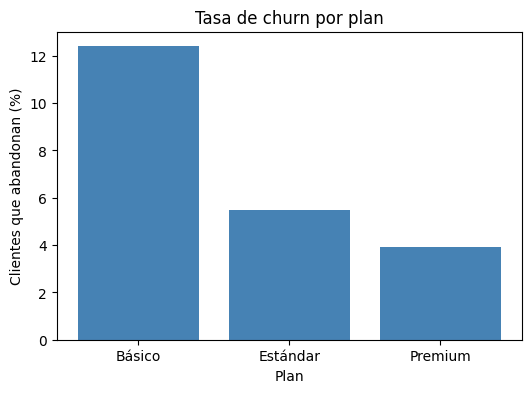

In [12]:
tabla = pd.crosstab(d["plan"], d["churn"])
tabla["tasa_churn_%"] = (tabla[1] / tabla.sum(axis=1) * 100).round(1)
print(tabla)

plt.figure(figsize=(6, 4))
plt.bar(tabla.index, tabla["tasa_churn_%"], color="steelblue")
plt.title("Tasa de churn por plan")
plt.xlabel("Plan")
plt.ylabel("Clientes que abandonan (%)")
plt.show()

El abandono cambia según el plan: 12.4% en Básico (95 de 769 clientes), 5.5% en Estándar y 3.9% en Premium. Básico concentra 95 de los 146 abandonos (65%) siendo el 42.7% de la base.

## Fase 5 — Los cinco hallazgos

In [13]:
# Evidencia extra para los hallazgos 3 y 5
print(d.groupby("churn")[["satisfaccion", "tickets_soporte", "mora_dias", "antiguedad_meses", "sesiones_mes"]].mean().round(2))
print(pd.crosstab(d["sentimiento"], d["calificacion"]))

       satisfaccion  tickets_soporte  mora_dias  antiguedad_meses  sesiones_mes
churn                                                                          
0              8.30             0.86       3.52             22.04         14.39
1              7.48             1.51       6.04             12.67         10.68
calificacion  2   3    4    5
sentimiento                  
negativo      2  27   60   59
neutral       3  78  147   39
positivo      0  23  439  923


1. **Los clientes Premium presentan un gasto promedio unas 3 veces mayor que los Básico, y no porque ganen más.** Evidencia: gasto medio de $828 contra $270; ingreso medio de $31,653 contra $31,291.

2. **El plan Básico presenta una tasa de churn mucho mayor que Estándar y Premium.** Evidencia: 12.4% contra 5.5% y 3.9%.

3. **Los clientes que abandonan están menos satisfechos y usan menos la app que los que se quedan.** Evidencia (abandonan contra se quedan): satisfacción 7.48 contra 8.30, tickets 1.51 contra 0.86, mora 6.04 contra 3.52 días, antigüedad 12.7 contra 22.0 meses y sesiones 10.7 contra 14.4.

4. **El gasto mensual se asocia con el uso de la app y no con el ingreso ni la edad.** Evidencia: correlación con el gasto de 0.32 (sesiones), 0.00 (ingreso) y 0.01 (edad).

5. **Hay datos sospechosos que revisar antes de modelar.** Evidencia: 40 duplicados exactos, ingreso máximo de $326,069, 8,752 minutos de app en un mes y 59 de 148 clientes con sentimiento negativo que dieron calificación 5.

Las diferencias del hallazgo 3 son de promedios y no prueban la causa del abandono.

## Preguntas de reflexión

1. **¿Cuál fue el hallazgo más sorprendente?** Que el ingreso no tiene relación con el gasto (r = 0.00) ni con el plan: esperaba que quien gana más contratara planes más caros. También que el churn de Básico sea 3 veces el de Premium.

2. **¿Encontraste algún dato sospechoso?** Sí: los 40 duplicados, el ingreso de $326,069, los 8,752 minutos de app y los 59 clientes con reseña negativa pero calificación de 5. También que `review` tenga solo 17 textos distintos.

3. **¿Qué variable investigarías con mayor profundidad?** `sesiones_mes`, porque se relaciona con el gasto y con el abandono, y es la que el negocio podría mover con campañas de uso.

4. **¿Qué hipótesis surgió durante el EDA?** Que el abandono depende más del perfil de uso (pocas sesiones, más tickets, más mora) que del plan en sí, y que Básico tiene más churn porque concentra a más clientes con ese perfil.

## Conclusión final

Después de auditar 1,840 registros (1,800 clientes únicos), concluyo que el abandono se explica más por el uso y la experiencia del servicio que por el ingreso. Los clientes que abandonan (8.1%) usan menos la app, abren más tickets, se atrasan más y están menos satisfechos, y se concentran en el plan Básico (12.4% de churn contra 3.9% en Premium). El gasto sube con el plan y con el uso, no con el ingreso.

El archivo sirve, pero antes de modelar hay que quitar los 40 duplicados, decidir qué hacer con los nulos (máximo 3.4%) y revisar los valores extremos y las reseñas contradictorias. Son asociaciones, no causas.